## Data Loading and Exploration (Task - 1)

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Importing libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv("Housing.csv")

In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
print(df.shape)

(545, 13)


In [6]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## Data Cleaning (Task - 2)

In [9]:
print(df.duplicated().sum())

0


In [10]:
df.select_dtypes(include='object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [11]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'mainroad',
        'guestroom',
        'basement',
        'hotwaterheating',
        'airconditioning',
        'prefarea',
        'furnishingstatus'
    ],
    drop_first=True
)

In [12]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [13]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

In [14]:
bool_cols = df_encoded.select_dtypes(include='bool').columns

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [15]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [16]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

## Model Building (Task - 3)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [19]:
print(X_train.shape)
print(X_test.shape)

(436, 13)
(109, 13)


In [20]:
lr_pred = lr.predict(X_test)

In [21]:
# Evaluation metrics in Linear Regression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)
print("MAE:",lr_mae)

print("RMSE:", lr_rmse
      )

print("R2:",
      )

MAE: 970043.403920164
RMSE: 1324506.9600914388
R2:


In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=2,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [23]:
# Evaluation metrics in Random Forest

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

MAE: 1047988.3508822453
RMSE: 1416057.218574194
R2: 0.6032861453018232


In [24]:
# Feature importance
rf.feature_importances_

array([0.48659964, 0.04037154, 0.16626671, 0.05053037, 0.04756164,
       0.00787963, 0.01502826, 0.0328746 , 0.01353791, 0.06173458,
       0.02931728, 0.01037285, 0.03792499])

In [25]:
# Check number of rows
df.shape

(545, 13)

<Axes: xlabel='price', ylabel='Count'>

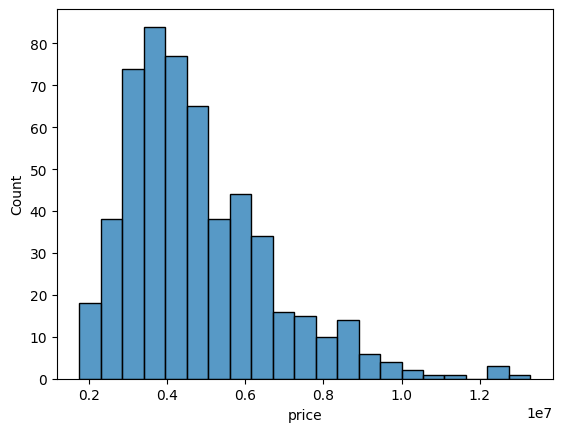

In [26]:
# Check target distribution
sns.histplot(df['price'])

In [27]:
train_r2 = rf.score(X_train, y_train)
test_r2 = rf.score(X_test, y_test)

print("Train:", train_r2)
print("Test:", test_r2)

Train: 0.8836488252208704
Test: 0.6032861453018232


In [28]:
# Comparison between the models

comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[lr_mae, rf_mae],
    "RMSE":[lr_rmse, rf_rmse],
    "R2":[lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.047988e+06,1.416057e+06,0.603286


## Visualization (Task - 4)

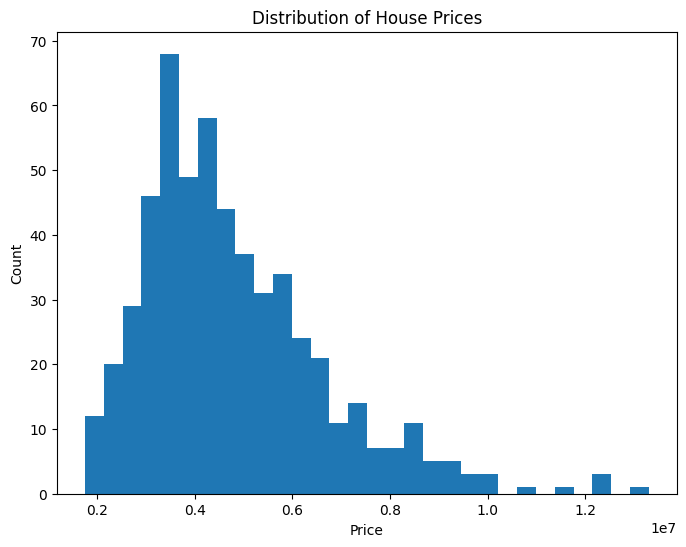

In [29]:
# Distribution of House prices

plt.figure(figsize=(8,6))
plt.hist(df['price'], bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of House Prices")
plt.savefig("charts/distribution_of_prices.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

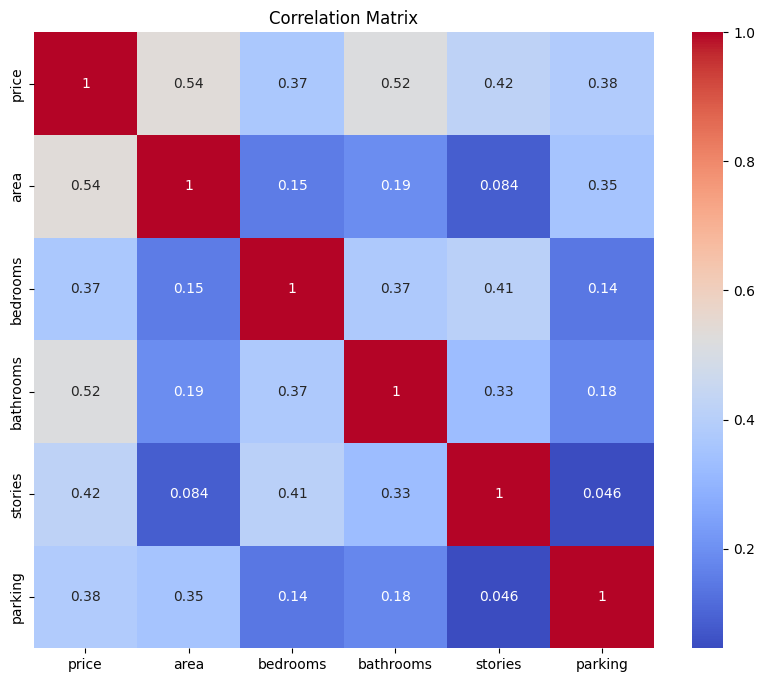

In [30]:
# Correlation Heatmap

import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.savefig("charts/correlation_plot.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

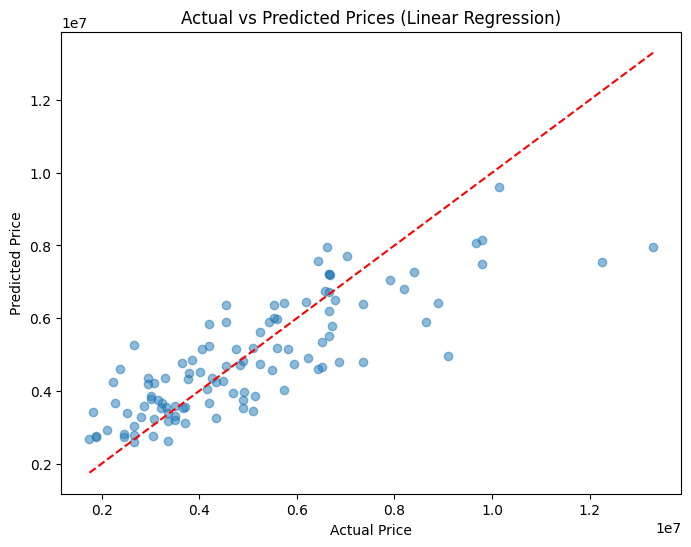

In [31]:
# Actual vs Predicted prices

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Linear Regression)")
plt.savefig("charts/actual_vs_predicted.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

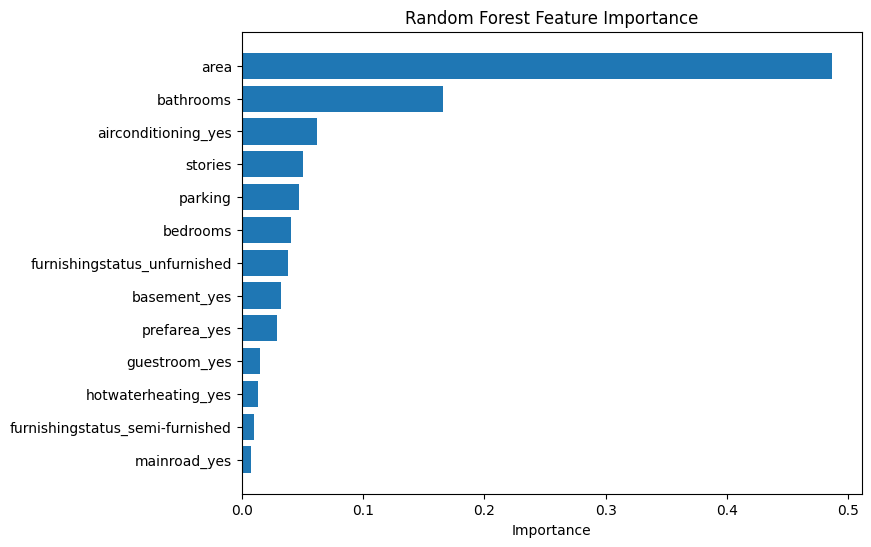

In [32]:
# Feature importance Graph - Random Forest

import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(8,6))
plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.savefig("charts/feature_importance.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

## Summary of my findings in this project (Task - 5)


Based on the feature importance analysis, the most influential factors affecting house prices were the top-ranked features in the dataset, 
with the leading feature contributing nearly 47% of the model's predictive power. The Linear Regression model achieved the best performance with an 
R2 score of 0.653, meaning it was able to explain about 65% of the variation in house prices. This indicates that the model provides reasonably 
accurate predictions, although some prediction errors remain.

My surprising finding was that the Random Forest model performed worse than Linear Regression, suggesting that the relationships in the data are largely linear rather than highly complex. For a real estate business, focusing on the most influential property characteristics identified by the model could help improve pricing strategies and better estimate market values.

### Conclusion
This project successfully demonstrated the use of machine learning for house price prediction. After preprocessing the data and converting categorical variables into numerical form, both Linear Regression and Random Forest models were trained. Linear Regression achieved the best performance with an R² score of approximately 65%, indicating a moderate level of predictive accuracy. The analysis showed that property area, bathrooms, parking, and air conditioning are among the most important factors influencing house prices. With additional data and feature engineering, the model's accuracy could be improved further, making it a useful tool for real estate pricing and decision-making.